# 00 -- Configuration & Data Inventory

Everything the pipeline needs (constants, file->class mapping, exclusions) lives
in **one place**: `pdm_common.py`. This notebook only *displays* that config so
you can see exactly what goes into the model and why, without hunting through
code. Nothing here is duplicated -- if a constant changes in `pdm_common.py`,
this notebook reflects it automatically next run.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline
import pdm_common as P

# If your raw logs are not next to this repo, point PDM_RAW_DIR at them
# (or set the env var before launching Jupyter) -- nothing else to edit.
# P.RAW_DIR = Path(r"C:\path\to\raw")
print("RAW_DIR:", P.RAW_DIR)
print("ART_DIR:", P.ART_DIR)


RAW_DIR: E:\DRDO\Sarthak Dhaigude_DRDO
ART_DIR: E:\DRDO\Sarthak Dhaigude_DRDO\PdM-main\artifacts


## Pipeline constants (all documented in `pdm_common.py`, no hidden magic numbers)

In [2]:
import pandas as pd
const = pd.DataFrame([
    ("fault injection time",  f"{P.FAULT_T} s"),
    ("nominal stop time",     f"{P.STOP_T} s"),
    ("baseline (pre-fault) window", f"{P.BASELINE_WIN} s"),
    ("resample rate",         f"{P.FS} Hz"),
    ("window length",         f"{P.WINDOW_SEC} s ({int(P.WINDOW_SEC*P.FS)} samples)"),
    ("window stride",         f"{int(P.STRIDE_FRAC*100)}%"),
    ("min windows / run",     P.MIN_WINDOWS),
    ("low-variance feature floor", P.LOW_VAR_THRESH),
    ("non-negative-by-physics signals", ", ".join(P.NONNEGATIVE_SIGNALS)),
], columns=["constant", "value"])
const

,constant,value
0,fault injection time,0.1 s
1,nominal stop time,0.3 s
2,baseline (pre-fault) window,"(0.05, 0.1) s"
3,resample rate,10000 Hz
4,window length,0.02 s (200 samples)
5,window stride,50%
6,min windows / run,3
7,low-variance feature floor,0.0
8,non-negative-by-physics signals,"pressure, flow, fuel"


## Runs included in training

In [3]:
inv = pd.DataFrame([
    dict(file=f, label=s["label"], always_on=s["always_on"])
    for f, s in P.FILE_MAP.items()
])
inv

,file,label,always_on
0,Healthy Data 3.xlsx,Healthy,False
1,disp1_fault(0.5).xlsx,PumpDisplacement,False
2,disp2_fault(0.3).xlsx,PumpDisplacement,False
3,disp3_fault(0.2).xlsx,PumpDisplacement,False
4,pump_disp(st-0.5).xlsx,PumpDisplacement,False
5,Leakage_factor.xlsx,Leakage,False
6,leakage_fault(0.5).csv,Leakage,False
7,leakage_fault(1.0).csv,Leakage,False
8,MildFlexible_shaft.xlsx,FlexibleShaft,False
9,Medium_FlexibleShaft_Fault.xlsx,FlexibleShaft,False


## Runs excluded (evidence-based reasons, not guesses)

In [4]:
exc = pd.DataFrame([dict(file=f, reason=why) for f, why in P.EXCLUDED.items()])
exc

,file,reason
0,healthy data 1.xlsx,only 0-0.002 s captured (startup only); non-ph...
1,Healthy data 2.xlsx,identical to healthy data 1: 0-0.002 s startup...
2,X_Sevear_FlexibleShaft_Fault.xlsx,span 0-0.005 s < fault time 0.1 s: NO fault-ac...
3,X_Critical_FlexibleShaft_Fault.xlsx,span 0-0.125 s -> fault region only ~0.025 s <...
4,Pump_Displacement.xlsx,byte-identical duplicate of disp1_fault(0.5) (...
5,simplifiied-generator-fault2(st-0.5).xlsx,near-identical re-export of simplifiied-genera...


## Runs per class

label
PumpDisplacement    4
Leakage             3
GeneratorFault      3
FlexibleShaft       2
Healthy             1
Name: count, dtype: int64

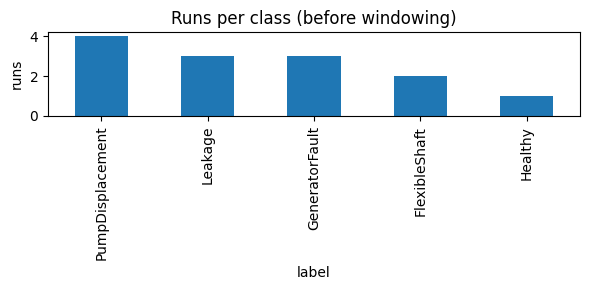

In [5]:
counts = inv["label"].value_counts()
ax = counts.plot.bar(figsize=(6, 3), title="Runs per class (before windowing)")
ax.set_ylabel("runs"); ax.figure.tight_layout()
counts